# Project notebook


In this notebook you can see how to access all the information connected to an existing project in CKG database.
The steps to generate an analytical report for a project are:

1) Create a Project object with the project identifier

2) Build the project by gathering and processing all the data in the project

3) Generate statistical report

4) Visualize report

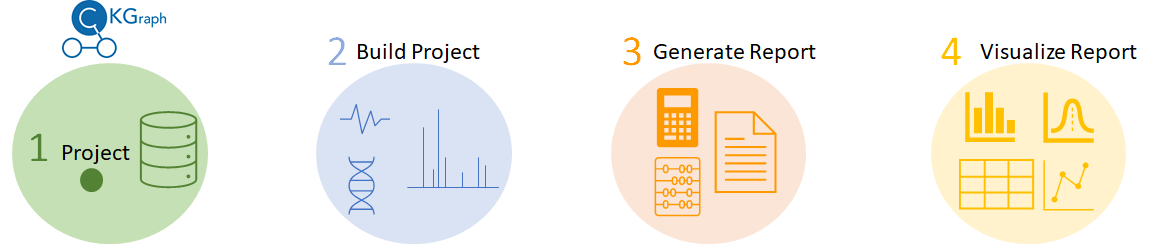

After these steps, all visualizations and statistical results defined in the configuration files will be available for further exploration or analysis. For instance:

- Original dataframe
- Processed dataframe
- Differential regulation results
- Correlation matrix
- Associations to Diseases, Drugs, Pathways, etc.

This recipe notebook shows also how to access these dataframes.

## Library import

In [ ]:
from ckg.report_manager import project

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
%matplotlib inline

## 1 Creating a Project object

This creates a project object with the identifier of an existing project. When default parameters are used, CKG will obtain all the data from the database when building the project. 

If no specific configuration files are provided for any of the data types, CKG will run the default analytical pipeline define for each one of them. When a different analysis is necessary, the path to the specific configuration file needs to be provided in the `configuration_files` dictionary. For instance:

``` python
p = project.Project(identifier='P0000001', configuration_files={'proteomics': 'path_to_my_customized_pipeline_configuration_file'}, datasets={}, knowledge=None, report={})
```

In [ ]:
p = project.Project(identifier='P0000001', configuration_files={}, datasets={}, knowledge=None, report={})

## 2 Build Project

Obtains all the data available for the project and processes each data type to get them ready for analysis.

The function `build_project` takes one argument *force*, if set to `False`, CKG will try to find an existing report in 'data/reports' and if the report was previously generated, it won't force building the project again. When *force* is set to `True` the project is built even if a previous report was generated.

In [ ]:
p.build_project(force=False)

## 3 Generate Project Report

In [ ]:
p.generate_report()

## 4 Visualizing the Project report

This code will show all the plots generated in the analysis. The function `show_report` takes an argument *environment* (string), which can take 2 values:

- app: used in the Dashboard
- notebook: to visualize the plots in a jupyter notebook



In [ ]:
plots = p.show_report(environment="notebook")

### Note: 
#### The result of the previous command is a dictionary where the keys correspond to the different tabs in the app ("Project information", "Clinical", "Proteomics", "Multiomics" and "Knowledge graph")

In [ ]:
plots.keys()

In [ ]:
plots['PROTEOMICS'][0]

In [ ]:
plots['PROTEOMICS'][1]

## Access to datasets

### Clinical data

In [ ]:
clin_dataset = p.get_dataset('clinical').get_dataframe('processed')
clin_dataset.head()

### Proteomics dataset (original)

In [ ]:
dataset = p.get_dataset("proteomics").get_dataframe("original")

In [ ]:
dataset.head()

### Proteomics dataset (processed)
After log transformation, filtering and imputation.

In [ ]:
proteomics = p.get_dataset("proteomics").get_dataframe("processed")

In [ ]:
proteomics

## Analyses results

#### Differential regulation: result from statistical analysis of the data

In [ ]:
reg_table = p.get_dataset("proteomics").get_dataframe("regulation table")
reg_table.head()